# **Latihan 1**

Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

masukin data yang dippt

In [ ]:
data = {
    'Temperatur': [10, 25, 15, 20, 18, 20, 22, 24],
    'Kecepatan_Angin': [0, 0, 5, 3, 7, 10, 5, 6],
    'Klasifikasi': ['Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin', 'Dingin', 'Panas', 'Panas']}

In [ ]:
df = pd.DataFrame(data)
print("--- Data Training ---")
print(df)
print("-" * 30)

--- Data Training ---
   Temperatur  Kecepatan_Angin Klasifikasi
0          10                0      Dingin
1          25                0       Panas
2          15                5      Dingin
3          20                3       Panas
4          18                7      Dingin
5          20               10      Dingin
6          22                5       Panas
7          24                6       Panas
------------------------------


Prediksi data

In [ ]:
X = df[['Temperatur', 'Kecepatan_Angin']]
y = df['Klasifikasi']

In [ ]:
data_baru = [[16, 3]]

coba dengan K=3

In [ ]:
k_prediksi = 3
knn = KNeighborsClassifier(n_neighbors=k_prediksi)
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
prediksi = knn.predict(data_baru)
distances, indices = knn.kneighbors(data_baru)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(f"\n>> Pertanyaan 1: Persepsi Marry saat Suhu 16°C & Angin 3 km/jam?")
print(f"Hasil Prediksi (dengan K={k_prediksi}): {prediksi[0]}")
print(f"Tetangga Terdekat:")
for i in range(k_prediksi):
    idx = indices[0][i]
    dist = distances[0][i]
    label = df.iloc[idx]['Klasifikasi']
    print(f"  {i+1}. Data index {idx} (Jarak: {dist:.2f}) -> {label}")


>> Pertanyaan 1: Persepsi Marry saat Suhu 16°C & Angin 3 km/jam?
Hasil Prediksi (dengan K=3): Dingin
Tetangga Terdekat:
  1. Data index 2 (Jarak: 2.24) -> Dingin
  2. Data index 3 (Jarak: 4.00) -> Panas
  3. Data index 4 (Jarak: 4.47) -> Dingin


Menentukan nilai k terbaik

In [ ]:
print(f"\n>> Pertanyaan 2: Nilai K yang paling tepat?")
k_values = [1, 3, 5, 7]
best_k = 0
best_score = 0

print("Evaluasi Akurasi (menggunakan Leave-One-Out):")
for k in k_values:
    knn_eval = KNeighborsClassifier(n_neighbors=k)
    # Cross validation untuk mengecek akurasi jika 1 data dijadikan test, sisanya training
    scores = cross_val_score(knn_eval, X, y, cv=LeaveOneOut())
    mean_acc = scores.mean()
    print(f"  K={k} -> Akurasi: {mean_acc:.0%}")

    if mean_acc >= best_score:
        best_score = mean_acc
        best_k = k

print(f"\nKesimpulan: Nilai K terbaik adalah {best_k} dengan akurasi {best_score:.0%}")


>> Pertanyaan 2: Nilai K yang paling tepat?
Evaluasi Akurasi (menggunakan Leave-One-Out):
  K=1 -> Akurasi: 100%
  K=3 -> Akurasi: 75%
  K=5 -> Akurasi: 75%
  K=7 -> Akurasi: 0%

Kesimpulan: Nilai K terbaik adalah 1 dengan akurasi 100%


In [ ]:
X = df[['Temperatur', 'Kecepatan_Angin']]
y = df['Klasifikasi']

k_prediksi_latihan1 = 3
knn = KNeighborsClassifier(n_neighbors=k_prediksi_latihan1)
knn.fit(X, y)

test_data = np.array([[16, 3]])
prediction = knn.predict(test_data)

print("\nPrediksi untuk suhu 16°C dan angin 3 km/jam:")
print("==>", prediction[0])


Prediksi untuk suhu 16°C dan angin 3 km/jam:
==> Dingin


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Hasilnya adalah dingin

Tetangga terdekatnya adalah data (15, 5) [Dingin], (20, 3) [Panas], dan (18, 7) [Dingin]. Karena ada 2 Dingin dan 1 Panas, maka mayoritasnya adalah Dingin.

K=1 akurasi 100%.

K=3 dan K=5 akurasi 75%.

# **Latihan 2 Prediksi Kelulusan**

Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_train = pd.read_excel('/content/drive/MyDrive/praktikum_ml/praktikum10/data/kelulusan_train.xls')
df_test = pd.read_excel('/content/drive/MyDrive/praktikum_ml/praktikum10/data/kelulusan_test.xls')

In [ ]:
fitur = ['IPS 1', 'IPS 2', 'IPS 3', 'IPS 4', 'IPS 5', 'IPS 6', 'IPS 7', 'IPS 8', 'IPK']
target = 'STATUS KELULUSAN'

In [ ]:
df_train.columns = df_train.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

preprocessing data

In [ ]:
actual_features_train = [f for f in fitur if f in df_train.columns]
actual_features_test = [f for f in fitur if f in df_test.columns]

print(f"Fitur yang ditemukan: {len(actual_features_train)} kolom")

Fitur yang ditemukan: 9 kolom


In [ ]:
df_train[actual_features_train] = df_train[actual_features_train].fillna(df_train[actual_features_train].mean())
df_test[actual_features_test] = df_test[actual_features_test].fillna(df_test[actual_features_test].mean())

Siapkn x dan y

In [ ]:
X_train = df_train[actual_features_train]
y_train = df_train[target]
X_test = df_test[actual_features_test]
y_test = df_test[target]

Training model

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

Evaluasi

In [ ]:
y_pred = knn.predict(X_test)

print("\n--- HASIL AKHIR ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.2%}")


--- HASIL AKHIR ---
Akurasi: 90.34%


Confsn matriks

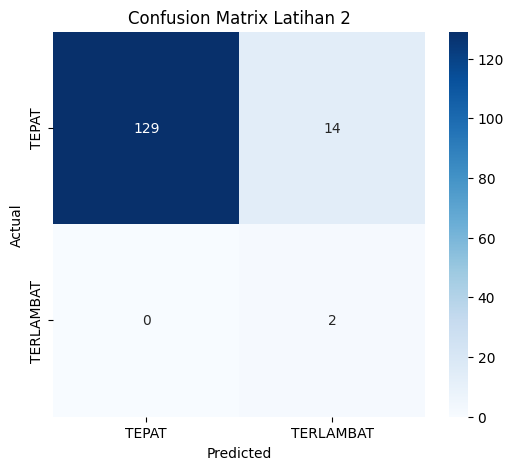

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title('Confusion Matrix Latihan 2')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       TEPAT       1.00      0.90      0.95       143
   TERLAMBAT       0.12      1.00      0.22         2

    accuracy                           0.90       145
   macro avg       0.56      0.95      0.59       145
weighted avg       0.99      0.90      0.94       145



# **Latihan 3 Prediksi Cuaca**

Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
path = ("/content/drive/MyDrive/praktikum_ml/praktikum10/data/weather_classification_data.csv")

In [ ]:
df_weather = pd.read_csv(path)
print("Data Awal:")
display(df_weather.head())

Data Awal:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


preprocessing

In [ ]:
df_proces = df_weather.copy()

In [ ]:
le = LabelEncoder()
kolom_kategori = ['Cloud Cover', 'Season', 'Location', 'Weather Type']

for col in kolom_kategori:
    df_proces[col] = le.fit_transform(df_proces[col])
    # Tampilkan contoh hasil perubahan
    print(f" -> Kolom '{col}' sudah diubah.")

 -> Kolom 'Cloud Cover' sudah diubah.
 -> Kolom 'Season' sudah diubah.
 -> Kolom 'Location' sudah diubah.
 -> Kolom 'Weather Type' sudah diubah.


Pisahkan fitur dan target

In [ ]:
X = df_proces.drop('Weather Type', axis=1)  # Penyebab
y = df_proces['Weather Type']               # Hasil Prediksi

Normalisasi

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Bagi data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Latih model

In [ ]:
print("\nMelatih model KNN (K=5)")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


Melatih model KNN (K=5)


KNeighborsClassifier()

Evaluasi hasil

In [ ]:
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [ ]:
print(f"\n=== HASIL AKHIR LATIHAN 3 ===")
print(f"Akurasi Model: {acc:.2%}")
print("\nLaporan Klasifikasi Lengkap:")
print(classification_report(y_test, y_pred))


=== HASIL AKHIR LATIHAN 3 ===
Akurasi Model: 89.20%

Laporan Klasifikasi Lengkap:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       651
           1       0.86      0.88      0.87       647
           2       0.93      0.93      0.93       701
           3       0.93      0.87      0.90       641

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640

